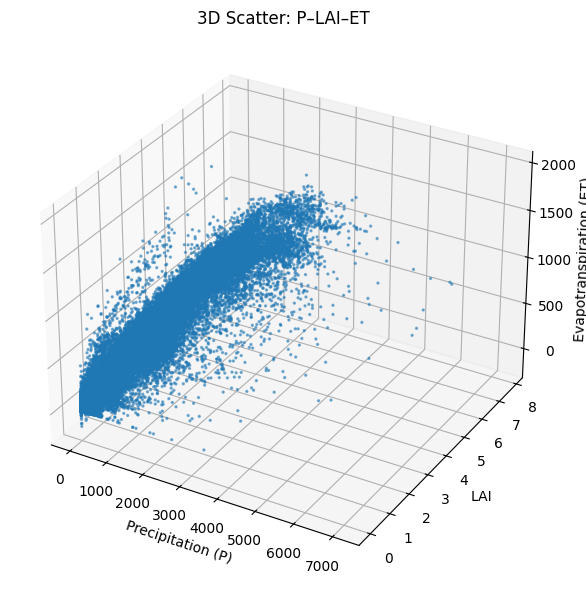

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 这一行虽然没直接用，但有时是为了触发 3D 支持

# 1. 读入数据
csv_path = "./classic_with_climate_zones.csv"   # 换成你的实际路径
df = pd.read_csv(csv_path)

# 可选：如果你担心 60000 多个点太多，可以随机抽样一部分
# 比如抽 10000 个点（不想抽样就注释掉这两行）
# df = df.sample(n=10000, random_state=0)

# 2. 取出三列：P, LAI, ET
x = df["precipitation"]   # x 轴：降水 P
y = df["lai"]             # y 轴：LAI
z = df["evapotrans"]      # z 轴：ET（蒸散）

# 3. 创建三维散点图
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

# s 控制点大小，60000+ 点建议小一点；alpha 让点略透明，便于看密集区域
ax.scatter(x, y, z, s=2, alpha=0.5)

# 4. 设置坐标轴标签
ax.set_xlabel("Precipitation (P)")
ax.set_ylabel("LAI")
ax.set_zlabel("Evapotranspiration (ET)")

# 可选：设置标题
ax.set_title("3D Scatter: P–LAI–ET")

plt.tight_layout()
plt.show()

总格点数: 61,826
bad_any=True 的格点数: 113 (0.18%)


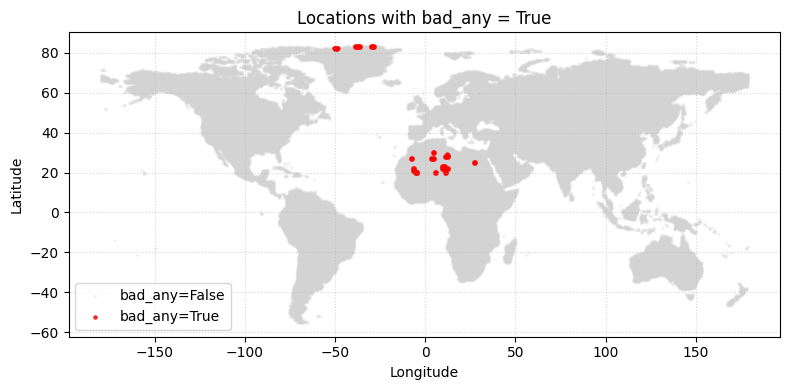

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读入数据
csv_path = "./classic_with_climate_zones.csv"   # 换成你的实际路径
df = pd.read_csv(csv_path)

# 如果你已经在 csv 里算好了 bad_any，就用现成的
# 如果想按“ET < T+E_veg+E_soil 或 P<ET”重算，可以用下面三行：
# df["bad_balance"] = df["evapotrans"] < (df["tran"] + df["evspsblveg"] + df["evspsblsoi"])
# df["bad_P"]       = df["precipitation"] < df["evapotrans"]
# df["bad_any"]     = df["bad_balance"] | df["bad_P"]

bad = df[df["bad_any"] == True]
good = df[df["bad_any"] == False]

print(f"总格点数: {len(df):,}")
print(f"bad_any=True 的格点数: {len(bad):,} ({len(bad)/len(df)*100:.2f}%)")

# 2. 作图：lon-x, lat-y 的散点
plt.figure(figsize=(8, 4))

# 先画所有正常点（淡灰色）
plt.scatter(good["lon"], good["lat"], s=2, alpha=0.2, label="bad_any=False", color="lightgray")

# 再画 bad_any=True 的点（红色）
plt.scatter(bad["lon"], bad["lat"], s=5, alpha=0.8, label="bad_any=True", color="red")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Locations with bad_any = True")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

总格点数: 61,826
bad_any=True 的格点数: 10,488 (16.96%)


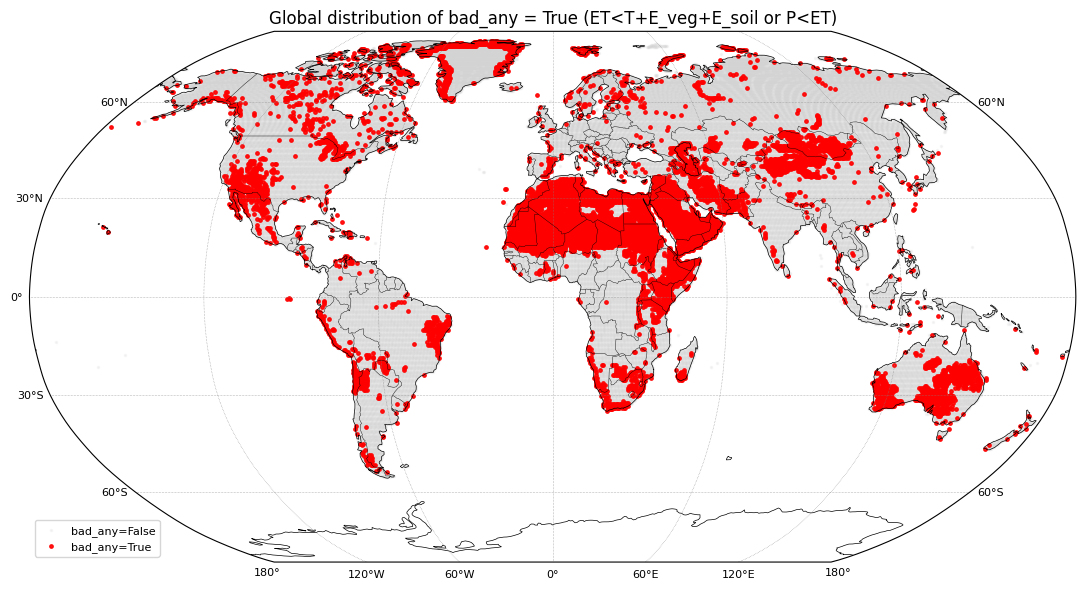

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读入数据
csv_path = "./classic_with_climate_zones.csv"   # 换成你的实际路径
df = pd.read_csv(csv_path)

# 可选：重新计算 bad_any
df["bad_balance"] = df["evapotrans"] < (df["tran"] + df["evspsblveg"] + df["evspsblsoi"])
df["bad_P"]       = df["precipitation"] < df["evapotrans"]
# df["bad_any"]     = df["bad_balance"] | df["bad_P"]
df["bad_any"]     =  df["bad_P"]

bad = df[df["bad_any"] == True]
good = df[df["bad_any"] == False]

print(f"总格点数: {len(df):,}")
print(f"bad_any=True 的格点数: {len(bad):,} ({len(bad)/len(df)*100:.2f}%)")

# 2. 画 Robinson 投影地图
fig = plt.figure(figsize=(12, 6))
proj = ccrs.Robinson()
ax = plt.axes(projection=proj)

# 底图元素
ax.set_global()
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", linestyle=":")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

# 绘制点
ax.scatter(
    good["lon"], good["lat"],
    s=2, alpha=0.2,
    transform=ccrs.PlateCarree(),
    color="lightgray",
    label="bad_any=False"
)

ax.scatter(
    bad["lon"], bad["lat"],
    s=6, alpha=0.9,
    transform=ccrs.PlateCarree(),
    color="red",
    label="bad_any=True"
)

ax.set_title("Global distribution of bad_any = True (ET<T+E_veg+E_soil or P<ET)", fontsize=12)
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

In [9]:
bad_balance_ratio = df["bad_balance"].mean() * 100
bad_P_ratio = df["bad_P"].mean() * 100
print(f"bad_balance = {bad_balance_ratio:.2f}%")
print(f"bad_P       = {bad_P_ratio:.2f}%")

bad_balance = 46.77%
bad_P       = 16.96%


=== 总体统计 ===
总格点数: 55,969
异常格点数 (任意<0 或 ET>1.5P): 0 (0.00%)

=== 各变量负值统计 ===
               负值点数  占比(%)
precipitation     0    0.0
lai               0    0.0
evapotrans        0    0.0
tran              0    0.0
evspsblveg        0    0.0
evspsblsoi        0    0.0


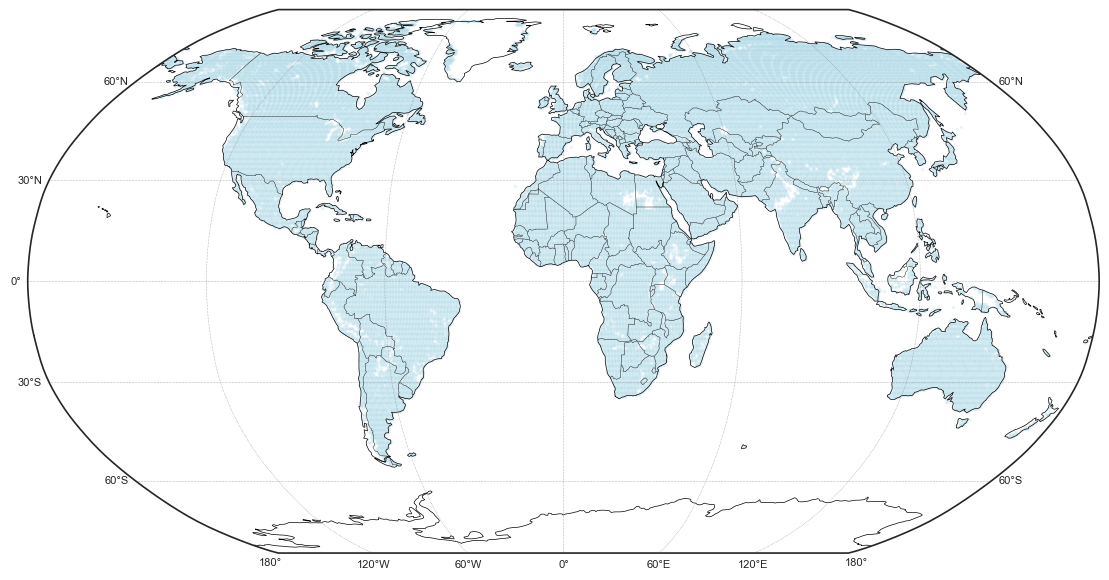

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读入数据
csv_path = "lpj_guess_with_climate_zones_filtered.csv"   # 换成你的实际路径
df = pd.read_csv(csv_path)

# 2. 定义字段
cols = ["precipitation", "lai", "evapotrans", "tran", "evspsblveg", "evspsblsoi"]

# 3. 计算负值标志
for col in cols:
    df[f"bad_{col}"] = df[col] < 0

# 4. 计算 ET > 1.5 * P
df["bad_ET_P_ratio"] = df["evapotrans"] > 1.5 * df["precipitation"]


# 5. 综合标志：任意负值 或 ET>1.5P
df["bad_any"] = df[[f"bad_{c}" for c in cols]].any(axis=1) 
# df["bad_any"] = df[[f"bad_{c}" for c in cols]].any(axis=1) | df["bad_ET_P_ratio"]

# 6. 分组
bad = df[df["bad_any"] == True]
good = df[df["bad_any"] == False]

# 7. 输出统计结果
print("=== 总体统计 ===")
print(f"总格点数: {len(df):,}")
print(f"异常格点数 (任意<0 或 ET>1.5P): {len(bad):,} ({len(bad)/len(df)*100:.2f}%)")

# 各变量负值数量
print("\n=== 各变量负值统计 ===")
summary = pd.DataFrame({
    "负值点数": [df[f"bad_{c}"].sum() for c in cols],
    "占比(%)": [df[f"bad_{c}"].mean() * 100 for c in cols]
}, index=cols)
print(summary)

# 8. 绘图
fig = plt.figure(figsize=(12, 6))
proj = ccrs.Robinson()
ax = plt.axes(projection=proj)

# 底图
ax.set_global()
ax.coastlines(linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="grey", linestyle=":")
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 8}
gl.ylabel_style = {"size": 8}

# 绘制点
ax.scatter(
    good["lon"], good["lat"],
    s=2, alpha=0.2,
    transform=ccrs.PlateCarree(),
    color="lightblue",
    label="Normal (All ≥0 and ET ≤ 1.5P)"
)

ax.scatter(
    bad["lon"], bad["lat"],
    s=8, alpha=0.9,
    transform=ccrs.PlateCarree(),
    color="red",
    label="Abnormal (Any <0 or ET > 1.5P)"
)

# ax.set_title("Global distribution of abnormal grid points (Any <0 or ET > 1.5×P)", fontsize=12)
# ax.legend(loc="lower left", fontsize=8)
ax.set_facecolor('none')
plt.gcf().patch.set_alpha(0)

plt.tight_layout()
plt.show()

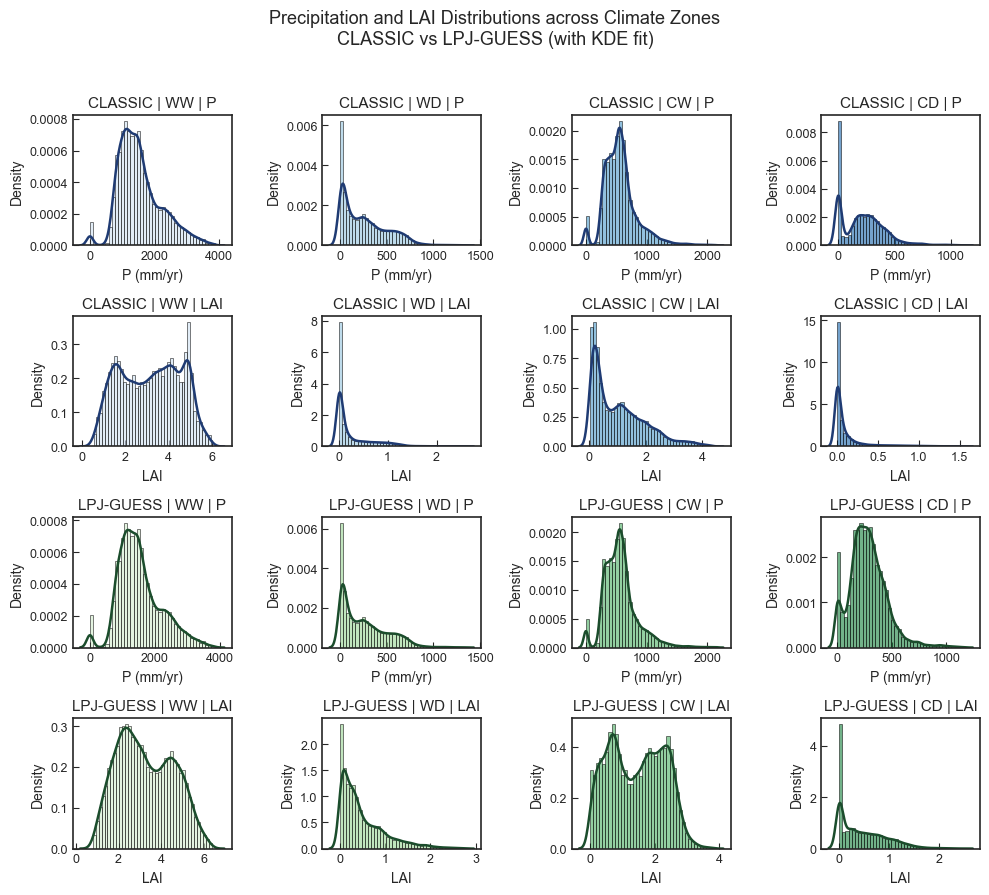

In [21]:
# -*- coding: utf-8 -*-
"""
4×4 分区直方图 + KDE拟合曲线（线条颜色优化版）
前两行 CLASSIC，后两行 LPJ-GUESS；
每行按气候区排列（HH, HD, CH, CD）；
奇数行为降水 P，偶数行为 LAI。
"""

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# ========= 1) 读取两个模型的数据 =========
classic_df = pd.read_csv("./classic_with_climate_zones_filtered.csv")
lpj_df     = pd.read_csv("./lpj_guess_with_climate_zones_filtered.csv")

zones = ["WW", "WD", "CW", "CD"]

# ========= 2) 样式设置 =========
sns.set_style("ticks")
mpl.rcParams.update({
    "axes.linewidth": 1.2,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

colors_classic = sns.color_palette("Blues", 4)
colors_lpj     = sns.color_palette("Greens", 4)

fig, axes = plt.subplots(4, 4, figsize=(10, 9), sharex=False, sharey=False)
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# ========= 3) 小函数：画直方图 + KDE曲线 =========
def plot_hist_kde(ax, data, bar_color, line_color, bins=40):
    # 直方图
    ax.hist(
        data,
        bins=bins,
        density=True,
        color=bar_color,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.6
    )
    # KDE曲线
    sns.kdeplot(
        data,
        ax=ax,
        color=line_color,
        linewidth=1.8
    )

# ========= 4) CLASSIC =========
for j, zone in enumerate(zones):
    sub = classic_df[classic_df["climate_zone"] == zone]
    line_color = "#1f3b73"  # 深蓝色线

    # 第1行：P
    ax_p = axes[0, j]
    plot_hist_kde(ax_p, sub["precipitation"], colors_classic[j], line_color)
    ax_p.set_title(f"CLASSIC | {zone} | P")
    if j == 0:
        ax_p.set_ylabel("Density")
    ax_p.set_xlabel("P (mm/yr)")

    # 第2行：LAI
    ax_lai = axes[1, j]
    plot_hist_kde(ax_lai, sub["lai"], colors_classic[j], line_color)
    ax_lai.set_title(f"CLASSIC | {zone} | LAI")
    if j == 0:
        ax_lai.set_ylabel("Density")
    ax_lai.set_xlabel("LAI")

# ========= 5) LPJ-GUESS =========
for j, zone in enumerate(zones):
    sub = lpj_df[lpj_df["climate_zone"] == zone]
    line_color = "#1b4d2c"  # 深绿色线

    # 第3行：P
    ax_p = axes[2, j]
    plot_hist_kde(ax_p, sub["precipitation"], colors_lpj[j], line_color)
    ax_p.set_title(f"LPJ-GUESS | {zone} | P")
    if j == 0:
        ax_p.set_ylabel("Density")
    ax_p.set_xlabel("P (mm/yr)")

    # 第4行：LAI
    ax_lai = axes[3, j]
    plot_hist_kde(ax_lai, sub["lai"], colors_lpj[j], line_color)
    ax_lai.set_title(f"LPJ-GUESS | {zone} | LAI")
    if j == 0:
        ax_lai.set_ylabel("Density")
    ax_lai.set_xlabel("LAI")

# ========= 6) 美化 =========
for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_visible(True)
    ax.tick_params(direction='in', length=4, width=0.8)

fig.suptitle(
    "Precipitation and LAI Distributions across Climate Zones\nCLASSIC vs LPJ-GUESS (with KDE fit)",
    fontsize=13,
    y=0.99
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

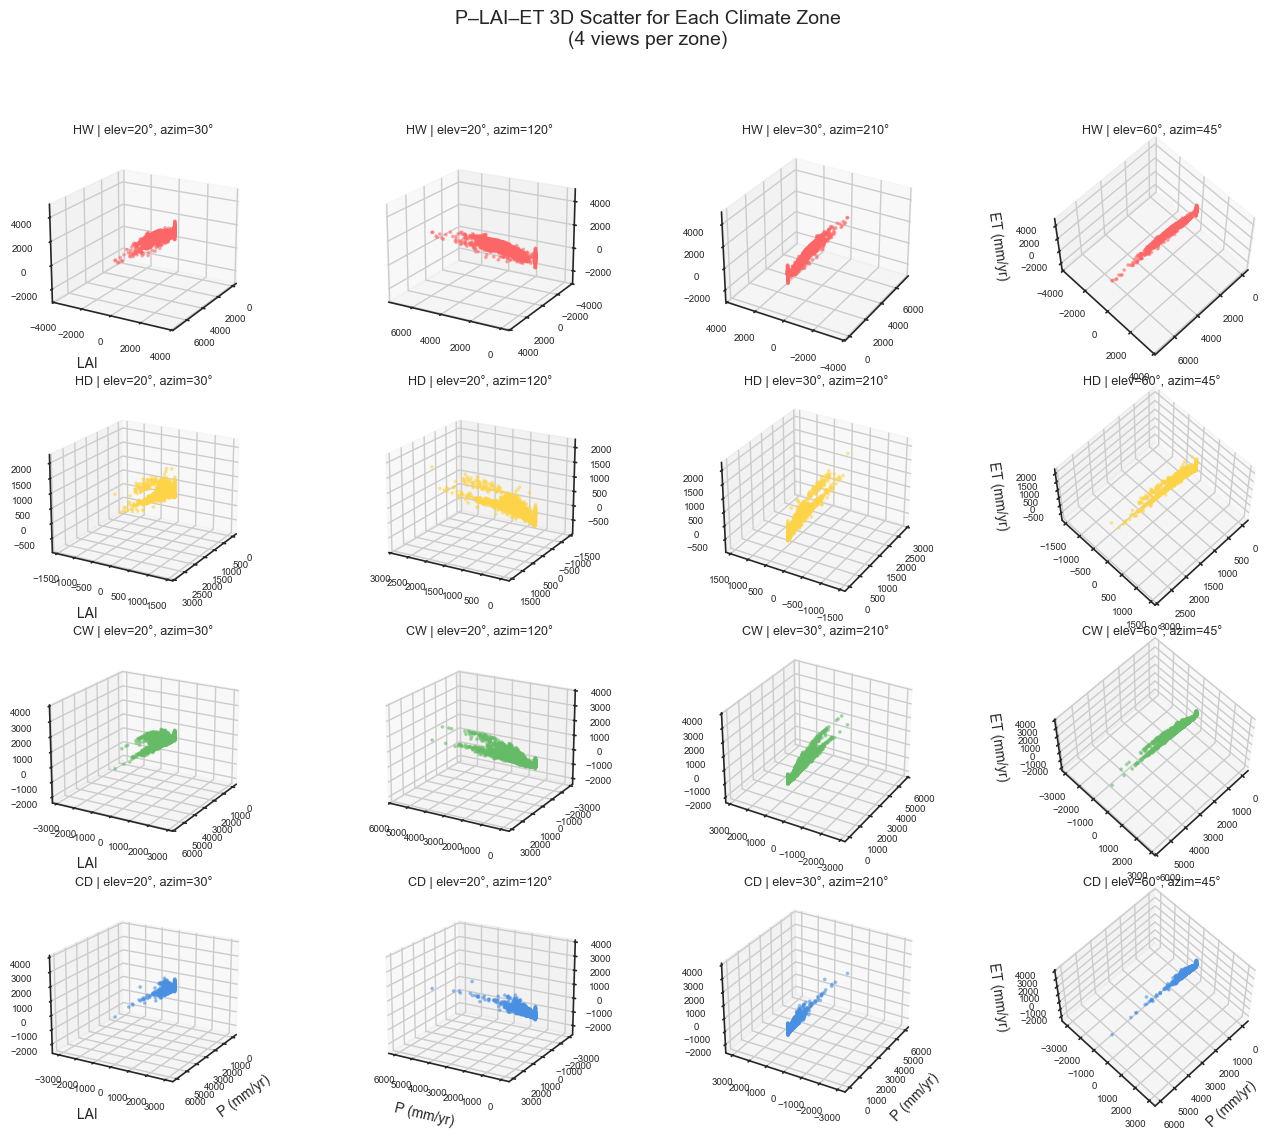

In [31]:
# -*- coding: utf-8 -*-
"""
P–LAI–ET 三维散点图：
x = P, y = LAI, z = ET
4 个气候区 × 4 个视角 = 4×4 子图矩阵
每一行是一个分区（HH/HD/CH/CD），每一列是一个视角。
"""

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# ============ 1) 读数据 ============
# 这里用 CLASSIC，如果想看 LPJ，就把文件换成 lpj 的即可
df = pd.read_csv("./classic_with_climate_zones.csv")

# 只保留需要的列
df = df[["precipitation", "lai", "evapotrans", "climate_zone"]].dropna()

# 也可以适当下采样，避免点太密（视情况打开）
# df = df.sample(30000, random_state=0)

# ============ 2) 气候区与颜色 ============
zones = ["HW", "HD", "CW", "CD"]   # 顺序 = 行顺序

zone_colors = {
    "HW": "#ff6666",  # 红色 Hot-Humid
    "HD": "#ffd447",  # 黄色 Hot-Dry
    "CW": "#66bb66",  # 绿色 Cold-Humid
    "CD": "#4a90e2",  # 蓝色 Cold-Dry
}

# 四个不同视角（列）：正面、侧面、背面、偏顶视
views = [
    (20,  30),   # elev, azim
    (20, 120),
    (30, 210),
    (60,  45),
]

# ============ 3) 画 4×4 3D 子图 ============
fig = plt.figure(figsize=(14, 12))

for i, zone in enumerate(zones):          # 行：分区
    sub = df[df["climate_zone"] == zone]
    color = zone_colors.get(zone, "gray")

    for j, (elev, azim) in enumerate(views):   # 列：视角
        ax = fig.add_subplot(4, 4, i*4 + j + 1, projection='3d')

        ax.scatter(
            sub["precipitation"],
            sub["lai"],
            sub["evapotrans"],
            s=3,
            alpha=0.45,
            color=color
        )

        # 坐标轴标签：只在左边一列/底部一行写，避免太挤
        if i == 3:     # 最后一行写 x label
            ax.set_xlabel("P (mm/yr)")
        else:
            ax.set_xlabel("")

        if j == 0:     # 第一列写 y label
            ax.set_ylabel("LAI")
        else:
            ax.set_ylabel("")

        if j == 3:     # 右边一列写 z label（或者你想改成第一列也行）
            ax.set_zlabel("ET (mm/yr)")
        else:
            ax.set_zlabel("")

        # 设置视角
        ax.view_init(elev=elev, azim=azim)

        # 子图标题：写分区+视角
        ax.set_title(f"{zone} | elev={elev}°, azim={azim}°", fontsize=9)

        # 让三轴比例更均衡（避免被压扁）
        xlim = ax.get_xlim3d()
        ylim = ax.get_ylim3d()
        zlim = ax.get_zlim3d()
        xrange = xlim[1] - xlim[0]
        yrange = ylim[1] - ylim[0]
        zrange = zlim[1] - zlim[0]
        max_range = max(xrange, yrange, zrange)

        x_middle = sum(xlim) / 2.0
        y_middle = sum(ylim) / 2.0
        z_middle = sum(zlim) / 2.0

        ax.set_xlim3d(x_middle - max_range/2, x_middle + max_range/2)
        ax.set_ylim3d(y_middle - max_range/2, y_middle + max_range/2)
        ax.set_zlim3d(z_middle - max_range/2, z_middle + max_range/2)

        # 刻度稍微紧一点
        ax.tick_params(labelsize=7)

fig.suptitle("P–LAI–ET 3D Scatter for Each Climate Zone\n(4 views per zone)", fontsize=14, y=0.93)
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

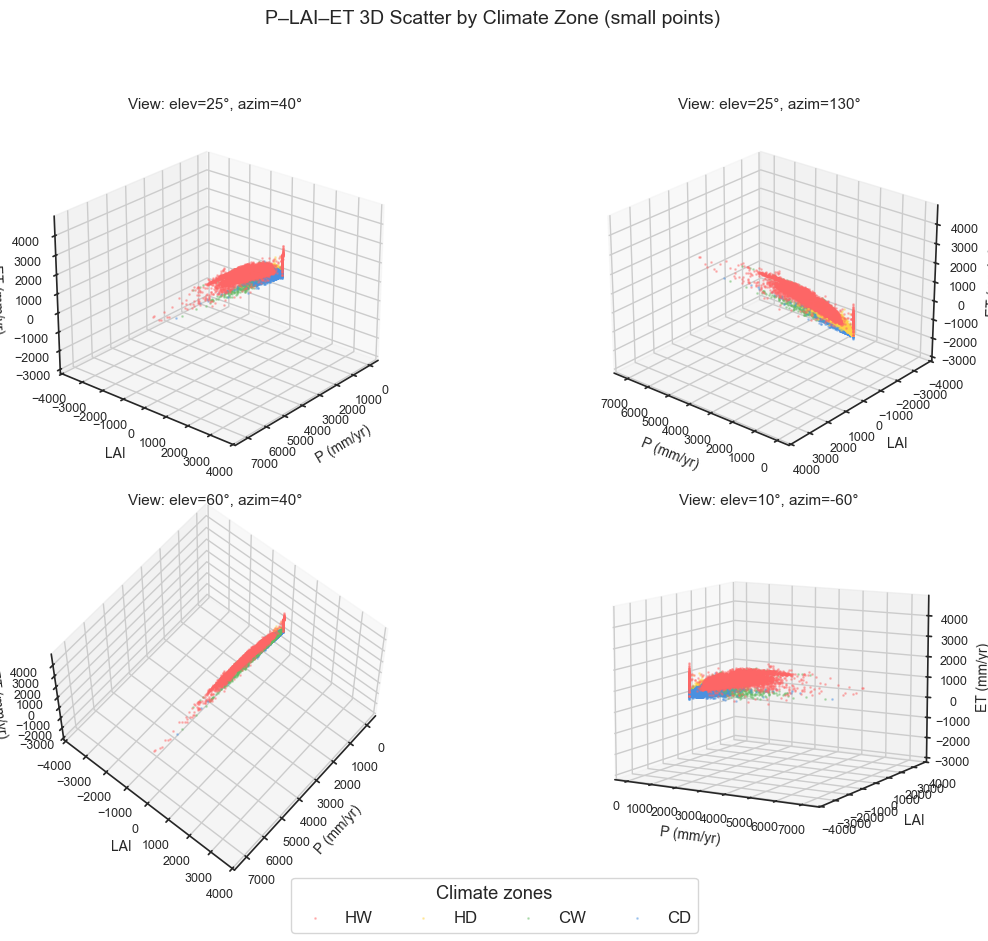

In [33]:
# -*- coding: utf-8 -*-
"""
3D 散点图：
x 轴 = P (precipitation)
y 轴 = LAI
z 轴 = ET (evapotrans)
点颜色按气候区 (HH, HD, CH, CD)，配色与 Koppen 图一致。
一次画出 4 个不同视角。
"""

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (只为触发 3D 支持)

# ============ 1) 读数据 ============
# 也可以换成 lpj 的 csv，只要列名一致就行
df = pd.read_csv("./classic_with_climate_zones.csv")

# 只保留需要的列
df = df[["precipitation", "lai", "evapotrans", "climate_zone"]].dropna()

# 可选：下采样，防止 3D 太密，如果想全部画就注释掉这一行
# df = df.sample(20000, random_state=0)

# ============ 2) 颜色映射（和地图配色一致） ============
# 你可以根据实际地图颜色微调
zone_colors = {
    "HW": "#ff6666",  # 红色 Hot-Humid
    "HD": "#ffd447",  # 黄色 Hot-Dry
    "CW": "#66bb66",  # 绿色 Cold-Humid
    "CD": "#4a90e2",  # 蓝色 Cold-Dry
}

zones = ["HW", "HD", "CW", "CD"]

# ============ 3) 2×2 不同视角 ============
fig = plt.figure(figsize=(12, 10))

# 视角组合：两个偏侧面 + 两个偏俯视
views = [
    (25,  40),   # 斜侧，看整体
    (25, 130),   # 反方向斜侧
    (60,  40),   # 偏俯视，更看 P–LAI 平面
    (10, -60),   # 更侧重看 ET 方向
]

for i, (elev, azim) in enumerate(views, start=1):
    ax = fig.add_subplot(2, 2, i, projection='3d')

    for z in zones:
        sub = df[df["climate_zone"] == z]
        ax.scatter(
            sub["precipitation"],
            sub["lai"],
            sub["evapotrans"],
            s=1.0,                     # ★ 点更小
            alpha=0.35,                # ★ 更透明，看密度
            color=zone_colors.get(z, "gray"),
            depthshade=False,          # ★ 避免遮挡太严重
            rasterized=True,           # ★ 导出成 pdf 时更清晰
            label=z if i == 1 else None
        )

    ax.set_xlabel("P (mm/yr)")
    ax.set_ylabel("LAI")
    ax.set_zlabel("ET (mm/yr)")

    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"View: elev={elev}°, azim={azim}°")

    # 为了让三个轴的范围尽量均衡一些（可选）
    xlim = ax.get_xlim3d()
    ylim = ax.get_ylim3d()
    zlim = ax.get_zlim3d()
    xrange = xlim[1] - xlim[0]
    yrange = ylim[1] - ylim[0]
    zrange = zlim[1] - zlim[0]
    max_range = max(xrange, yrange, zrange)

    x_middle = sum(xlim) / 2
    y_middle = sum(ylim) / 2
    z_middle = sum(zlim) / 2

    ax.set_xlim3d(x_middle - max_range/2, x_middle + max_range/2)
    ax.set_ylim3d(y_middle - max_range/2, y_middle + max_range/2)
    ax.set_zlim3d(z_middle - max_range/2, z_middle + max_range/2)

# 只在第一个子图加图例
handles, labels = fig.axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="lower center",
    ncol=4,
    title="Climate zones"
)

fig.suptitle("P–LAI–ET 3D Scatter by Climate Zone (small points)", fontsize=14, y=0.93)
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.show()

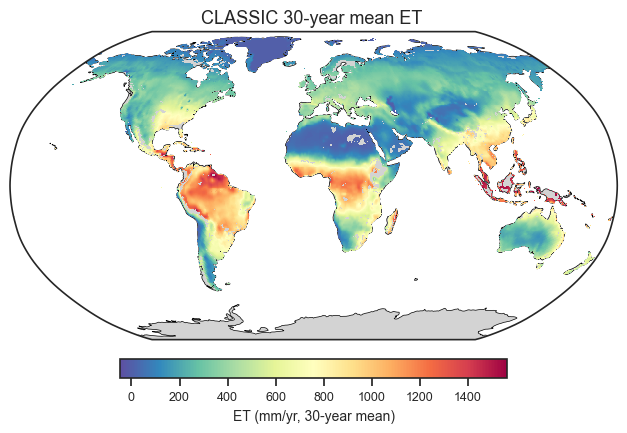

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. 读入数据
df = pd.read_csv("./classic_with_climate_zones_filtered.csv")   # 里面有 lat, lon, precipitation 等列


# 转为网格
grid = df.pivot(index="lat", columns="lon", values="evapotrans")
grid = grid.sort_index(axis=0)
grid = grid.sort_index(axis=1)

lats = grid.index.values
lons = grid.columns.values
et = grid.values

#========================
# 2. 绘图
#========================
fig = plt.figure(figsize=(10, 5))
proj = ccrs.Robinson(central_longitude=0)
ax = plt.axes(projection=proj)

ax.set_global()
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=1)

# 主图
pc = ax.pcolormesh(
    lons, lats, et,
    transform=ccrs.PlateCarree(),
    cmap="Spectral_r",       # ✅ 换成其他可选配色: "YlGnBu", "viridis", "turbo"
    shading="auto"
)

# 标题
ax.set_title("CLASSIC 30-year mean ET ", fontsize=13)

# 颜色条
cbar = plt.colorbar(pc, orientation="horizontal", pad=0.05, shrink=0.5)
cbar.set_label("ET (mm/yr, 30-year mean)")

plt.show()
# 保存成高分辨率图片用在 PPT

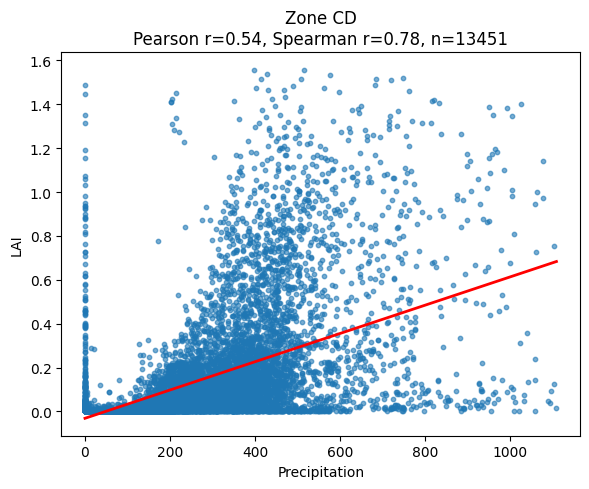

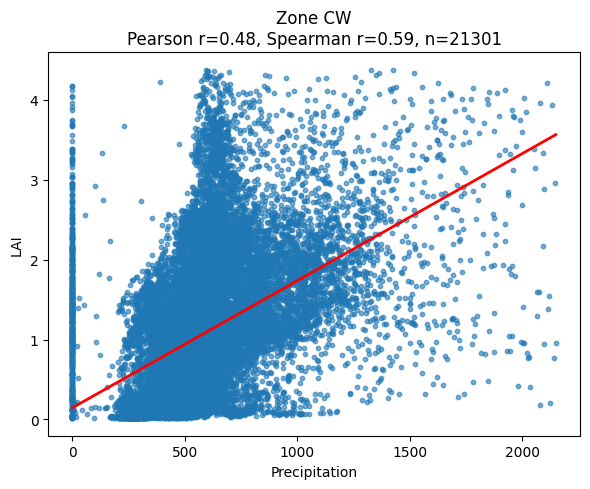

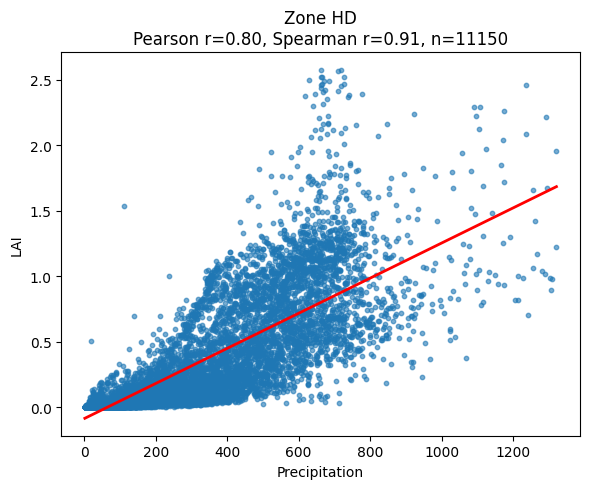

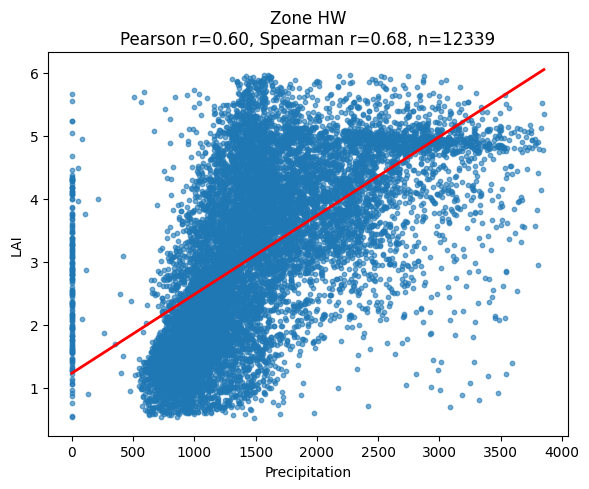

/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/mimi/miniconda3/envs/pip39/lib/python3.9/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


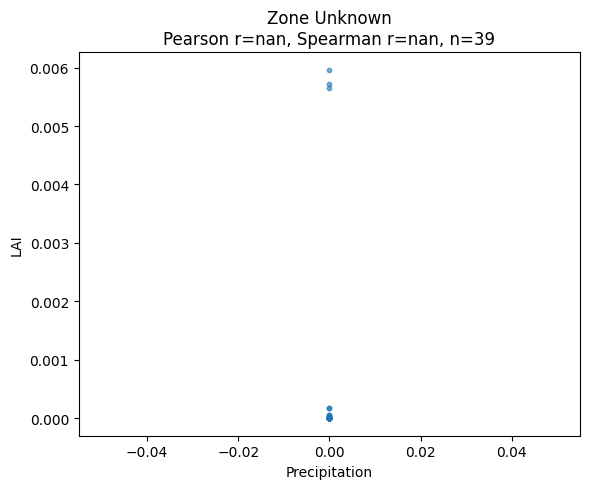

In [5]:
# correlation_analysis_display.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
df = pd.read_csv("classic_with_climate_zones_filtered.csv")

# 选择相关列
cols = ["lat","lon","precipitation","lai","climate_zone","is_outlier"]
df = df[cols].copy()

# 剔除异常点
if "is_outlier" in df.columns:
    df = df[df["is_outlier"] == False].copy()

# 删除缺失和非有限值
df = df.dropna(subset=["precipitation","lai","climate_zone"])
mask = np.isfinite(df["precipitation"]) & np.isfinite(df["lai"])
df = df.loc[mask]

zones = sorted(df["climate_zone"].astype(str).unique())

def safe_linregress(x, y):
    """解析解线性回归 (y = a*x + b)，防止奇异矩阵"""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    if len(x) < 3 or np.isclose(np.var(x), 0):
        return np.nan, np.nan, False
    a = np.cov(x, y, ddof=1)[0, 1] / np.var(x, ddof=1)
    b = np.mean(y) - a * np.mean(x)
    return a, b, True

# 按气候区绘图与分析
for z in zones:
    sub = df[df["climate_zone"] == z][["precipitation","lai"]].dropna()
    n = len(sub)
    if n < 3:
        print(f"Zone {z}: 样本不足，跳过。")
        continue

    x, y = sub["precipitation"].values, sub["lai"].values
    pearson_r  = np.corrcoef(x, y)[0, 1]
    spearman_r = pd.Series(x).corr(pd.Series(y), method="spearman")
    a, b, ok = safe_linregress(x, y)

    # 绘制散点 + 回归线
    plt.figure(figsize=(6,5))
    plt.scatter(x, y, s=10, alpha=0.6)
    if ok:
        xs = np.linspace(x.min(), x.max(), 100)
        plt.plot(xs, a*xs + b, color="red", linewidth=2)

    plt.title(f"Zone {z}\nPearson r={pearson_r:.2f}, Spearman r={spearman_r:.2f}, n={n}")
    plt.xlabel("Precipitation")
    plt.ylabel("LAI")
    plt.tight_layout()
    plt.show()


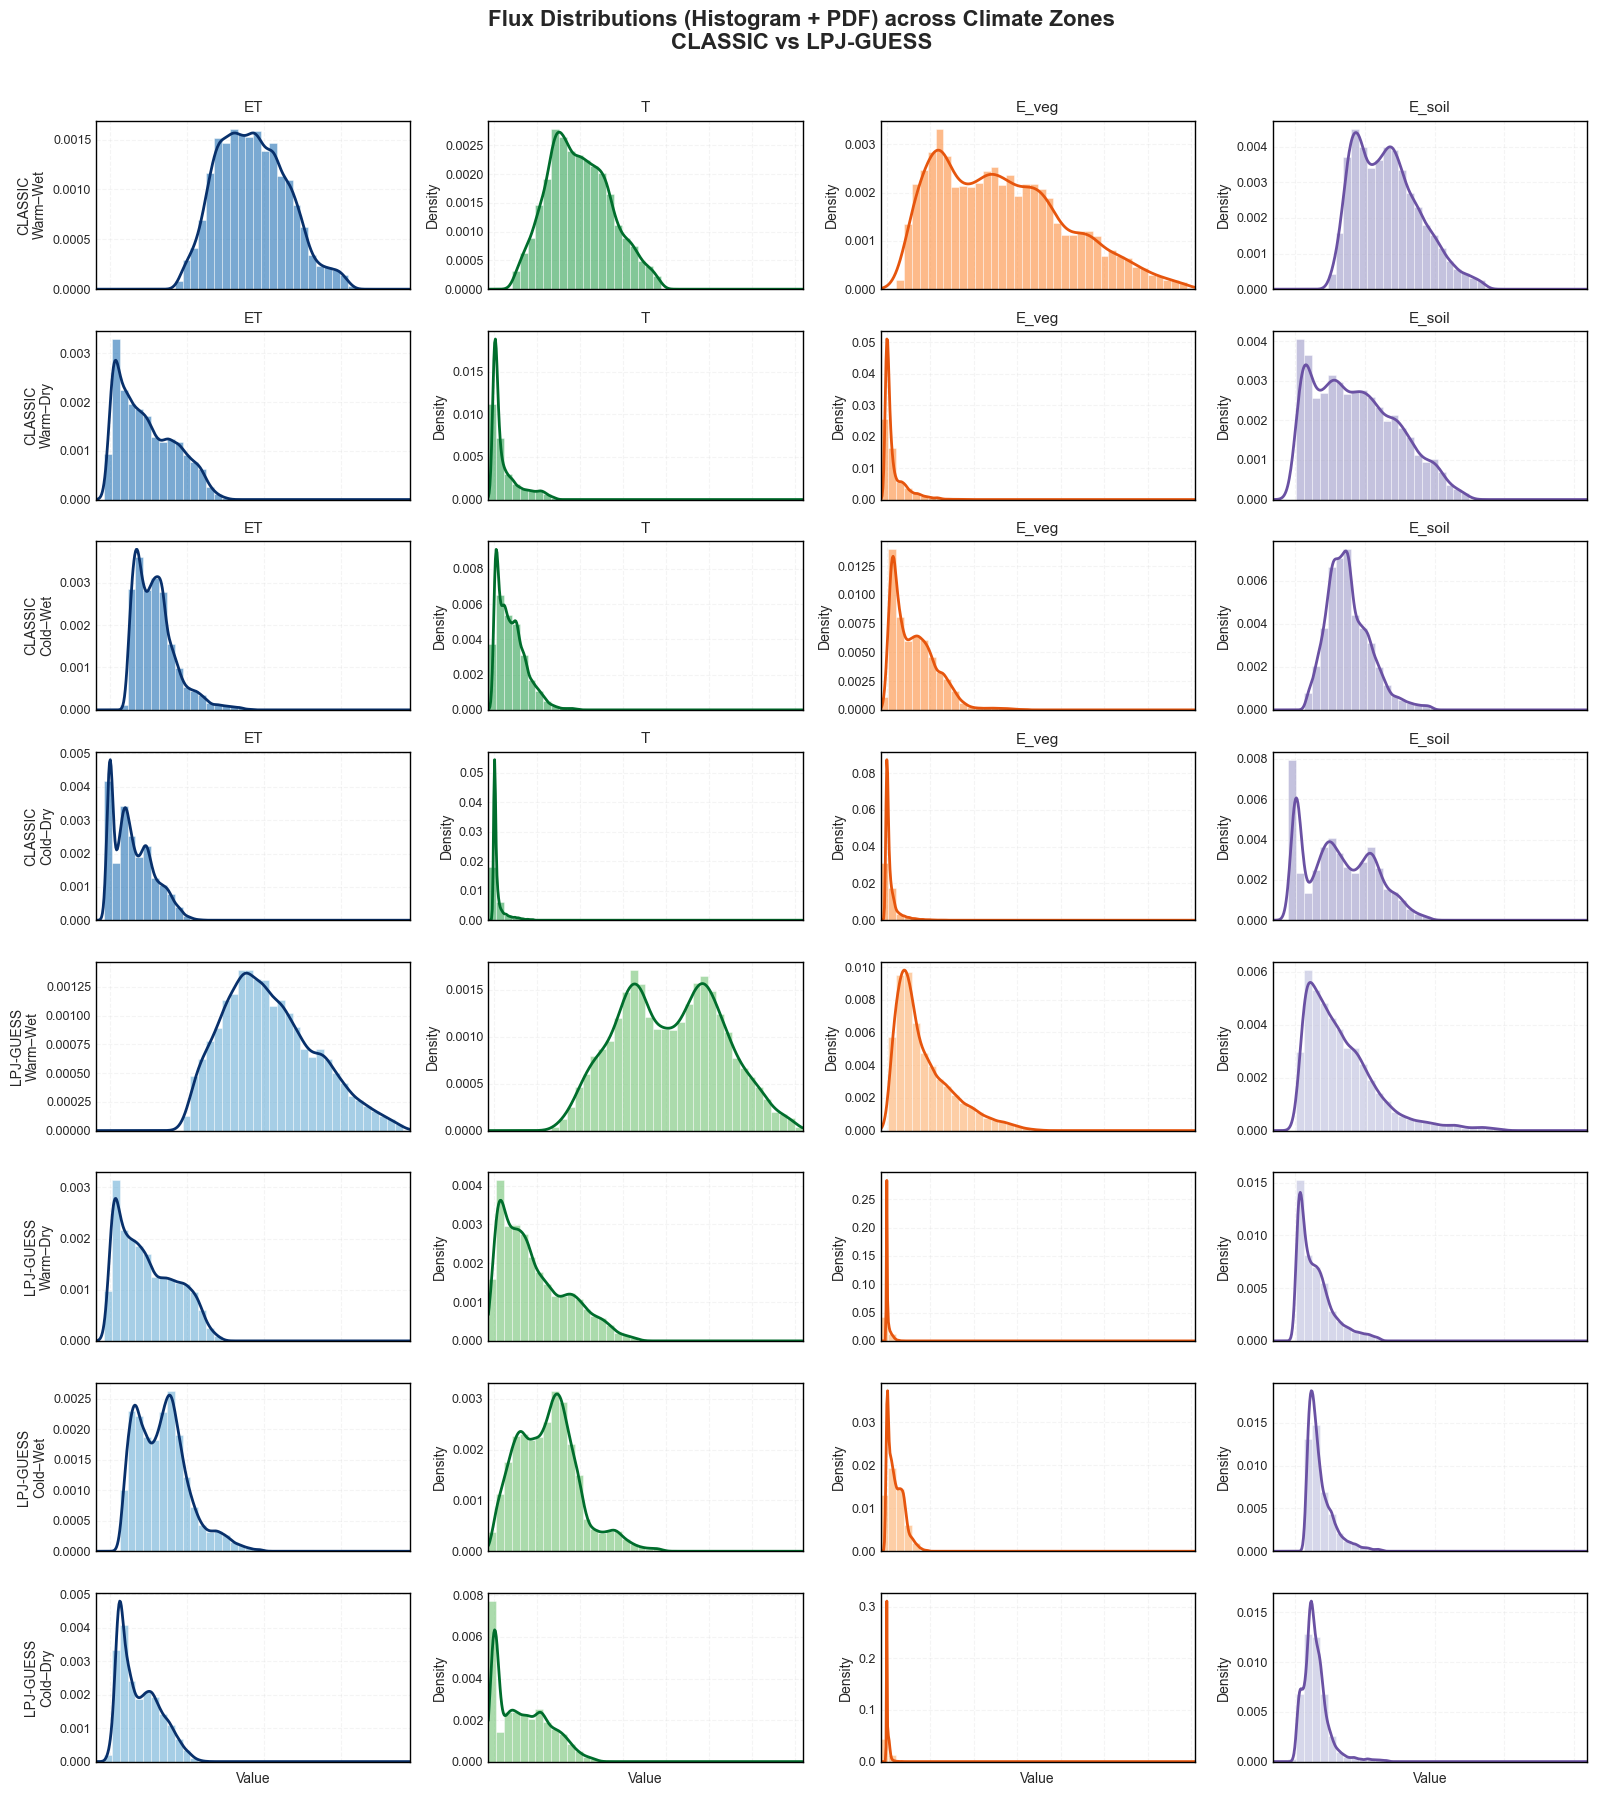

In [19]:
# -*- coding: utf-8 -*-
"""
8×4 复合分布图：每列为 ET/T/E_veg/E_soil，
每行对应 CLASSIC 和 LPJ-GUESS 各气候区。
展示直方图 + KDE 曲线，共用 x 轴，x 轴标签仅底部显示。
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ====== 文件路径 ======
classic_csv = "classic_with_climate_zones_filtered.csv"
lpj_csv     = "lpj_guess_with_climate_zones_filtered.csv"

# ====== 读取与清洗 ======
classic_df = pd.read_csv(classic_csv)
lpj_df     = pd.read_csv(lpj_csv)

for df in (classic_df, lpj_df):
    if "is_outlier" in df.columns:
        df = df[df["is_outlier"] == False]

# ====== 变量、标签、区域 ======
vars_cols   = ["evapotrans", "tran", "evspsblveg", "evspsblsoi"]
vars_labels = ["ET", "T", "E_veg", "E_soil"]
zones       = ["HW", "HD", "CW", "CD"]
zone_titles = {"HW": "Warm–Wet", "HD": "Warm–Dry", "CW": "Cold–Wet", "CD": "Cold–Dry"}

# 每列对应一套颜色系列
col_colors = [
    ["#c6dbef", "#6baed6", "#2171b5", "#08306b"],  # 蓝色系 (ET)
    ["#c7e9c0", "#74c476", "#31a354", "#006d2c"],  # 绿色系 (T)
    ["#fdd0a2", "#fdae6b", "#fd8d3c", "#e6550d"],  # 橙色系 (E_veg)
    ["#dadaeb", "#bcbddc", "#9e9ac8", "#6a51a3"],  # 紫色系 (E_soil)
]

# ====== 工具函数 ======
def finite_values(a):
    a = np.asarray(a, dtype=float)
    return a[np.isfinite(a)]

def get_global_range(df1, df2, col):
    """跨模型求统一范围"""
    vals = np.concatenate([finite_values(df1[col].values), finite_values(df2[col].values)])
    if vals.size == 0:
        return (0, 1)
    vmin, vmax = vals.min(), vals.max()
    pad = 0.02 * (vmax - vmin)
    return (vmin - pad, vmax + pad)

# ====== 全局范围 ======
x_ranges = {v: get_global_range(classic_df, lpj_df, v) for v in vars_cols}

# ====== 画布设置 ======
n_rows, n_cols = 8, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18), sharex="col")
plt.subplots_adjust(wspace=0.25, hspace=0.4)

def plot_hist_and_pdf(ax, data, xlim, color_hist, color_line):
    """画直方图 + KDE 曲线"""
    data = finite_values(data)
    if data.size < 5:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xlim(*xlim)
        return
    # 直方图
    ax.hist(data, bins=40, range=xlim, density=True,
            color=color_hist, alpha=0.6, edgecolor="white", linewidth=0.5)
    # KDE 曲线
    xs = np.linspace(xlim[0], xlim[1], 400)
    kde = gaussian_kde(data)
    ys = kde(xs)
    ax.plot(xs, ys, color=color_line, linewidth=2.0)
    ax.set_xlim(*xlim)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2, linestyle="--")
    for sp in ax.spines.values():
        sp.set_color("black")
        sp.set_linewidth(1.0)

# ====== 绘制 CLASSIC (上4行) + LPJ (下4行) ======
for r in range(4):
    zone = zones[r]
    sub = classic_df[classic_df["climate_zone"] == zone]
    for c in range(4):
        ax = axes[r, c]
        col = vars_cols[c]
        plot_hist_and_pdf(ax, sub[col], x_ranges[col],
                          color_hist=col_colors[c][2], color_line=col_colors[c][3])
        if c == 0:
            ax.set_ylabel(f"CLASSIC\n{zone_titles[zone]}", fontsize=10)
        ax.set_title(vars_labels[c], pad=6)

for r in range(4, 8):
    zone = zones[r - 4]
    sub = lpj_df[lpj_df["climate_zone"] == zone]
    for c in range(4):
        ax = axes[r, c]
        col = vars_cols[c]
        plot_hist_and_pdf(ax, sub[col], x_ranges[col],
                          color_hist=col_colors[c][1], color_line=col_colors[c][3])
        if c == 0:
            ax.set_ylabel(f"LPJ-GUESS\n{zone_titles[zone]}", fontsize=10)

# ====== x轴标签只显示最下面的 ======
for c in range(4):
    for r in range(n_rows - 1):
        axes[r, c].set_xlabel("")  # 清空上方
        axes[r, c].set_xticklabels([])  # 不显示刻度
    axes[n_rows - 1, c].set_xlabel("Value", fontsize=10)

# ====== 标题与整体黑边 ======
fig.suptitle("Flux Distributions (Histogram + PDF) across Climate Zones\nCLASSIC vs LPJ-GUESS",
             fontsize=16, fontweight="bold", y=0.995)

if hasattr(fig, "spines"):
    for sp in fig.spines.values():
        sp.set_edgecolor("black")
        sp.set_linewidth(1.2)

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.show()


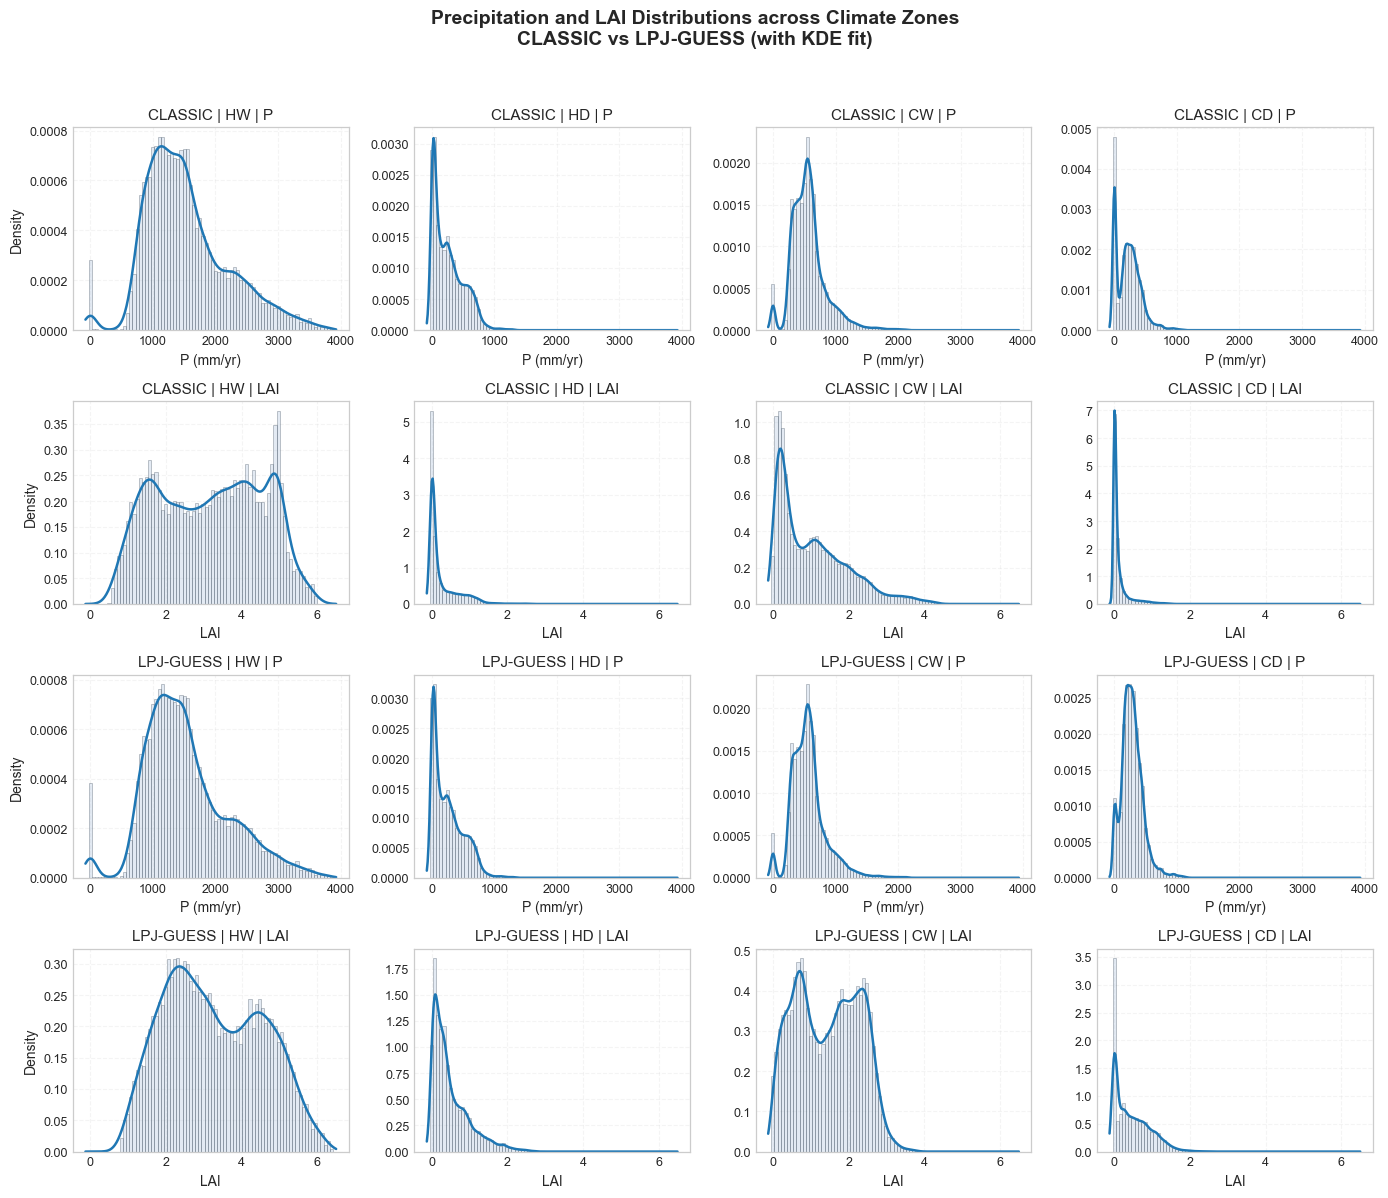

In [15]:
# -*- coding: utf-8 -*-
"""
4×4 子图：P 与 LAI 的分布（直方图 + KDE），风格同示例图
行：CLASSIC|P，CLASSIC|LAI，LPJ|P，LPJ|LAI
列：HW, HD, CW, CD
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ======= 路径 =======
classic_csv = "classic_with_climate_zones_filtered.csv"
lpj_csv     = "lpj_guess_with_climate_zones_filtered.csv"

# ======= 读取与清洗 =======
classic = pd.read_csv(classic_csv)
lpj     = pd.read_csv(lpj_csv)

# 可选剔除离群
if "is_outlier" in classic.columns:
    classic = classic[classic["is_outlier"] == False].copy()
if "is_outlier" in lpj.columns:
    lpj = lpj[lpj["is_outlier"] == False].copy()

# 只保留需要列并去掉非数值
keep_cols = ["climate_zone", "precipitation", "lai"]
classic = classic[keep_cols].dropna()
lpj     = lpj[keep_cols].dropna()

# 保证有限值
classic = classic[np.isfinite(classic["precipitation"]) & np.isfinite(classic["lai"])]
lpj     = lpj[np.isfinite(lpj["precipitation"]) & np.isfinite(lpj["lai"])]

zones = ["HW", "HD", "CW", "CD"]
zone_titles = {"HW": "Warm–Wet", "HD": "Warm–Dry", "CW": "Cold–Wet", "CD": "Cold–Dry"}

# ======= 工具函数 =======
def fd_bins(values, min_bins=25, max_bins=80):
    """Freedman–Diaconis 规则求 bins 数"""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < min_bins:
        return max(min_bins, int(np.sqrt(max(values.size, 1))))
    q1, q3 = np.percentile(values, [25, 75])
    iqr = q3 - q1
    data_rng = values.max() - values.min()
    if iqr <= 0 or data_rng <= 0:
        return min_bins
    bw = 2 * iqr / (values.size ** (1/3))
    if bw <= 0:
        return min_bins
    return int(np.clip(data_rng / bw, min_bins, max_bins))

def get_global_range_bins(df1, df2, col):
    """跨模型/分区计算全局范围与 bins，便于列内可比"""
    vals = np.concatenate([df1[col].values, df2[col].values])
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return (0.0, 1.0), 30
    vmin, vmax = float(vals.min()), float(vals.max())
    # 给两侧留一点边距
    pad = 0.02 * (vmax - vmin) if vmax > vmin else 0.1
    vmin -= pad; vmax += pad
    return (vmin, vmax), fd_bins(vals)

# 全局范围/分箱（每列固定）
(p_rng, p_bins)   = get_global_range_bins(classic, lpj, "precipitation")
(lai_rng, lai_bins) = get_global_range_bins(classic, lpj, "lai")

# ======= 画布与风格 =======
plt.rcParams.update({
    "axes.linewidth": 0.9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

fig, axes = plt.subplots(4, 4, figsize=(14, 12), sharey=False)
plt.subplots_adjust(wspace=0.25, hspace=0.35)

# 颜色与样式（直方图条纹 + KDE 线）
hist_fc = "#b0c4de"       # 浅蓝灰柱
hist_ec = "#2f4050"       # 深边框
kde_lw  = 1.8

def plot_hist_kde(ax, data, rng, bins, kde_color):
    """密度直方图 + KDE 曲线"""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if data.size < 3:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_xlim(*rng)
        return
    ax.hist(data, bins=bins, range=rng, density=True,
            edgecolor=hist_ec, linewidth=0.6, alpha=0.35, color=hist_fc)
    try:
        kde = gaussian_kde(data)
        xs = np.linspace(rng[0], rng[1], 300)
        ax.plot(xs, kde(xs), linewidth=kde_lw)
    except Exception:
        pass
    ax.grid(alpha=0.2, linestyle="--")

# ======= 绘制 4×4 =======
# 行 0: CLASSIC | P
# 行 1: CLASSIC | LAI
# 行 2: LPJ     | P
# 行 3: LPJ     | LAI
for c, z in enumerate(zones):
    # CLASSIC | P
    ax = axes[0, c]
    sub = classic.loc[classic["climate_zone"] == z, "precipitation"]
    plot_hist_kde(ax, sub, p_rng, p_bins, kde_color=None)
    ax.set_title(f"CLASSIC | {z} | P")
    if c == 0:
        ax.set_ylabel("Density")
    ax.set_xlabel("P (mm/yr)")

    # CLASSIC | LAI
    ax = axes[1, c]
    sub = classic.loc[classic["climate_zone"] == z, "lai"]
    plot_hist_kde(ax, sub, lai_rng, lai_bins, kde_color=None)
    ax.set_title(f"CLASSIC | {z} | LAI")
    if c == 0:
        ax.set_ylabel("Density")
    ax.set_xlabel("LAI")

    # LPJ | P
    ax = axes[2, c]
    sub = lpj.loc[lpj["climate_zone"] == z, "precipitation"]
    plot_hist_kde(ax, sub, p_rng, p_bins, kde_color=None)
    ax.set_title(f"LPJ-GUESS | {z} | P")
    if c == 0:
        ax.set_ylabel("Density")
    ax.set_xlabel("P (mm/yr)")

    # LPJ | LAI
    ax = axes[3, c]
    sub = lpj.loc[lpj["climate_zone"] == z, "lai"]
    plot_hist_kde(ax, sub, lai_rng, lai_bins, kde_color=None)
    ax.set_title(f"LPJ-GUESS | {z} | LAI")
    if c == 0:
        ax.set_ylabel("Density")
    ax.set_xlabel("LAI")

# 顶部总标题（两行）
fig.suptitle(
    "Precipitation and LAI Distributions across Climate Zones\n"
    "CLASSIC vs LPJ-GUESS (with KDE fit)",
    fontsize=14, fontweight="bold", y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
